In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path().resolve().parent

rfm = pd.read_csv(BASE_DIR / "data/processed/rfm_segments.csv")

rfm.head()

,customer_unique_id,frequency,monetary,recency,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,161,4,1,3,413,Recent
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,164,4,1,1,411,Recent
2,0000f46a3911fa3c0805444483337064,1,86.22,586,1,1,2,112,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,370,2,1,1,211,Lost
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,337,2,1,4,214,Lost


In [16]:
features = rfm[["recency", "frequency", "monetary"]]

# Initial K-Means Clustering

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

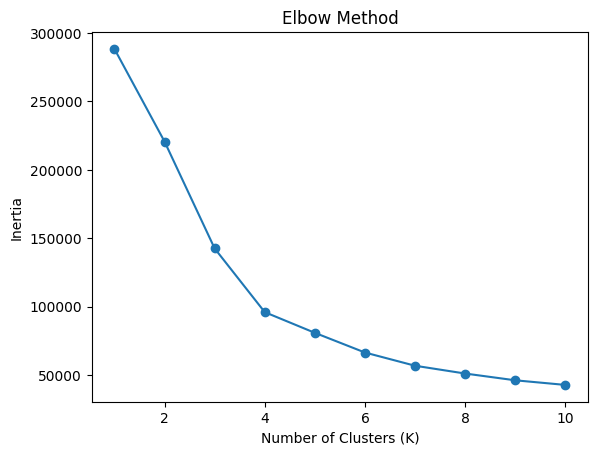

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [19]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["cluster"] = kmeans.fit_predict(scaled_features)

In [20]:
rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean()

,recency,frequency,monetary
cluster,,,
0,178.926315,1.000000,134.994652
1,439.542927,1.000000,134.644484
2,290.122914,1.015466,1189.062764
3,269.306212,2.116475,290.305945


<Axes: xlabel='recency', ylabel='monetary'>

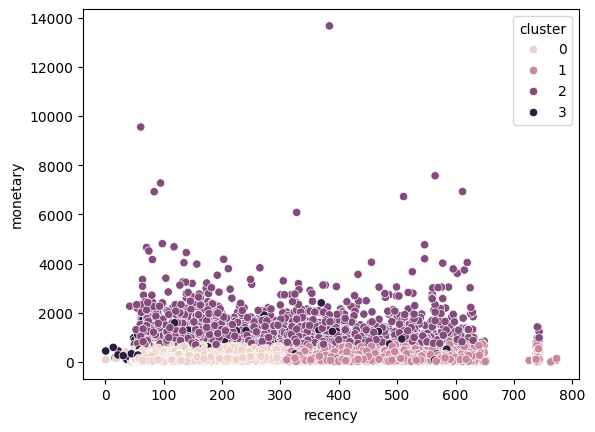

In [21]:
import seaborn as sns

sns.scatterplot(
    data=rfm,
    x="recency",
    y="monetary",
    hue="cluster"
)